In [1]:
# Install (uncomment if needed)
# !pip install torch torchvision matplotlib numpy scikit-learn tqdm

import tensorflow as tf
from tensorflow.keras import layers, models

import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as mpatches
import os
from skimage.io import imread

tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU(s) available: {[g.name for g in gpus]}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('No GPU found, using CPU')

print(f'TensorFlow version: {tf.__version__}')

GPU(s) available: ['/physical_device:GPU:0']
TensorFlow version: 2.20.0


## Section 2: Download Dataset

In [13]:
!wget https://zenodo.org/records/16948350/files/WHU_buildings.zip?download=1 -O WHU_buildings.zip
# Unzip
!unzip -q WHU_buildings.zip -d ./WHU_buildings

--2026-06-21 11:02:51--  https://zenodo.org/records/16948350/files/WHU_buildings.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.52.235, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116403828 (111M) [application/octet-stream]
Saving to: ‘WHU_buildings.zip’

WHU_buildings.zip   100%[===================>] 111.01M   688KB/s    in 3m 18s  

2026-06-21 11:06:10 (575 KB/s) - ‘WHU_buildings.zip’ saved [116403828/116403828]



In [2]:
img_dir = "WHU_buildings/Satellite dataset вё (global cities)/image"
mask_dir = "WHU_buildings//Satellite dataset вё (global cities)/label"

In [3]:
# --- 2. Load data ---
X, Y = [], []
files = sorted(os.listdir(img_dir))

for f in files:
    img = imread(os.path.join(img_dir, f))
    mask = imread(os.path.join(mask_dir, f.replace(".jpg", ".png"))).max(axis=-1)  # adjust ext

    # ensure mask is binary (0=background, 1=building)
    mask = (mask > 127).astype(np.uint8)

    X.append(img)
    Y.append(mask[..., np.newaxis])  # keep channel dimension

X = np.array(X, dtype=np.float32) / 255.0
Y = np.array(Y, dtype=np.float32)

print("Images:", X.shape, "Masks:", Y.shape)

Images: (204, 512, 512, 3) Masks: (204, 512, 512, 1)


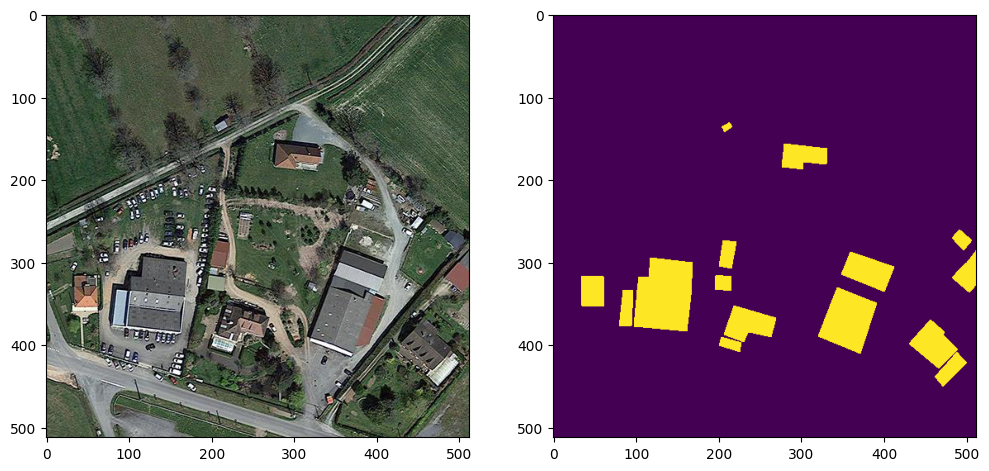

In [4]:
n = 120  # sample number
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(X[n])
ax[1].imshow(Y[n])

ax[0].ticklabel_format(useOffset=False, style="plain")
ax[1].ticklabel_format(useOffset=False, style="plain")

In [5]:
print(f'Loaded  X : {X.shape}  dtype={X.dtype}')
print(f'Loaded  Y : {Y.shape}  dtype={Y.dtype}')
print(f'X range   : [{X.min():.1f}, {X.max():.1f}]')
print(f'Y classes : {np.unique(Y)}')

# ── 2. Normalise to [0, 1] ───────────────────────────────────────────────────
X = X.astype(np.float32)
if X.max() > 1.5:
    X = X / 10000.0
X = np.clip(X, 0.0, 1.0)

# ── 3. Ensure channels-last layout (N, H, W, C) for TensorFlow ──────────────
#       Raw files are often channels-first (N, C, H, W); detect and transpose.
if X.ndim == 4 and X.shape[1] < X.shape[-1]:
    X = X.transpose(0, 2, 3, 1)  # (N, C, H, W) → (N, H, W, C)

Y = Y.astype(np.int32)
n_samples = X.shape[0]
img_h, img_w, n_channels = X.shape[1], X.shape[2], X.shape[3]
print(f'\nAfter pre-processing:')
print(f'  X : {X.shape}  (N, H, W, C)')
print(f'  Y : {Y.shape}')
print(f'  n_channels={n_channels}   image size={img_h}x{img_w}')

# ── 4. Extract 128x128 patches ───────────────────────────────────────────────
PATCH_SIZE = 128

def make_patches(X_arr, Y_arr, patch_size=128, stride=128):
    patches = []
    for img, lbl in zip(X_arr, Y_arr):
        h, w = img.shape[0], img.shape[1]
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                patches.append((
                    img[y:y+patch_size, x:x+patch_size, :],  # (H, W, C)
                    lbl[y:y+patch_size, x:x+patch_size]       # (H, W)
                ))
    return patches

if img_h == PATCH_SIZE and img_w == PATCH_SIZE:
    all_patches = list(zip(X, Y))
else:
    all_patches = make_patches(X, Y, patch_size=PATCH_SIZE, stride=PATCH_SIZE)

print(f'\nTotal patches : {len(all_patches)}')
print(f'Patch image   : {all_patches[0][0].shape}')
print(f'Patch label   : {all_patches[0][1].shape}')

# ── 5. Train / validation split (80 / 20, fixed seed) ───────────────────────
rng     = np.random.RandomState(42)
indices = rng.permutation(len(all_patches))
split   = int(0.8 * len(indices))
train_patches = [all_patches[i] for i in indices[:split]]
val_patches   = [all_patches[i] for i in indices[split:]]
print(f'\nTrain patches : {len(train_patches)}')
print(f'Val   patches : {len(val_patches)}')

# ── 6. Build a full-resolution scene for Section 10 inference ───────────────
if img_h > PATCH_SIZE:
    scene_img   = X[0]    # (H, W, C)
    scene_label = Y[0]    # (H, W)
else:
    side = 4
    rows_img, rows_lbl = [], []
    for row in range(side):
        cols_img, cols_lbl = [], []
        for col in range(side):
            p_img, p_lbl = val_patches[(row * side + col) % len(val_patches)]
            cols_img.append(p_img)
            cols_lbl.append(p_lbl)
        rows_img.append(np.concatenate(cols_img, axis=1))   # concat along W
        rows_lbl.append(np.concatenate(cols_lbl, axis=1))
    scene_img   = np.concatenate(rows_img, axis=0)   # (4*ps, 4*ps, C)
    scene_label = np.concatenate(rows_lbl, axis=0)   # (4*ps, 4*ps)

print(f'\nScene image : {scene_img.shape}')
print(f'Scene label : {scene_label.shape}')

# ── 7. Class metadata ────────────────────────────────────────────────────────
N_CLASSES = int(Y.max()) + 1
_default_names  = ['Background', 'Building', 'Water', 'Vegetation']
_default_colors = ['#D2B48C',   '#E8534A', '#4A90D9', '#5CA854']
CLASS_NAMES  = _default_names[:N_CLASSES]  + [f'Class {i}' for i in range(4, N_CLASSES)]
CLASS_COLORS = _default_colors[:N_CLASSES] + ['#9B59B6', '#F39C12', '#1ABC9C', '#E74C3C'][:max(0, N_CLASSES-4)]
print(f'\nDetected {N_CLASSES} classes -> {CLASS_NAMES}')

Loaded  X : (204, 512, 512, 3)  dtype=float32
Loaded  Y : (204, 512, 512, 1)  dtype=float32
X range   : [0.0, 1.0]
Y classes : [0. 1.]

After pre-processing:
  X : (204, 512, 512, 3)  (N, H, W, C)
  Y : (204, 512, 512, 1)
  n_channels=3   image size=512x512

Total patches : 3264
Patch image   : (128, 128, 3)
Patch label   : (128, 128, 1)

Train patches : 2611
Val   patches : 653

Scene image : (512, 512, 3)
Scene label : (512, 512, 1)

Detected 2 classes -> ['Background', 'Building']


In [6]:
len(all_patches)

3264

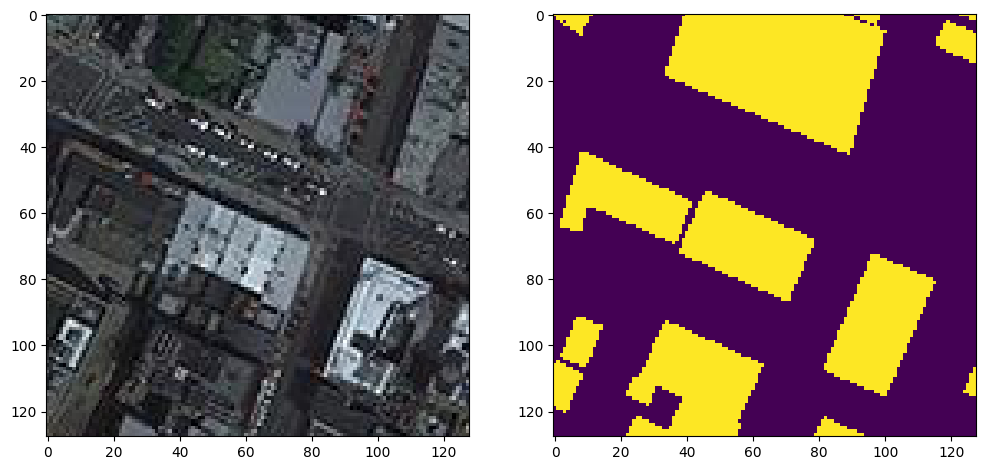

In [7]:
n = 1354  # sample number
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(all_patches[n][0])
ax[1].imshow(all_patches[n][1])

ax[0].ticklabel_format(useOffset=False, style="plain")
ax[1].ticklabel_format(useOffset=False, style="plain")

In [8]:
def augment(img, lbl):
    """Synchronized random flip + 90-degree rotation."""
    # Stack so both receive the exact same transform
    lbl_float = tf.cast(lbl[..., tf.newaxis], img.dtype)   # (H, W, 1)
    stacked = tf.concat([img, lbl_float], axis=-1)          # (H, W, C+1)

    stacked = tf.image.random_flip_left_right(stacked)
    stacked = tf.image.random_flip_up_down(stacked)

    k = tf.random.uniform((), 0, 4, dtype=tf.int32)
    stacked = tf.image.rot90(stacked, k)

    img_out = stacked[..., :n_channels]
    lbl_out = tf.cast(stacked[..., n_channels], lbl.dtype)
    return img_out, lbl_out


def make_tf_dataset(patches, batch_size=8, augment_fn=None, shuffle=True):
    imgs = np.stack([p[0] for p in patches]).astype(np.float32)
    lbls = np.stack([p[1] for p in patches]).astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((imgs, lbls))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(patches), seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


BATCH_SIZE = 8
train_ds = make_tf_dataset(train_patches, batch_size=BATCH_SIZE, augment_fn=augment, shuffle=True)
val_ds   = make_tf_dataset(val_patches,   batch_size=BATCH_SIZE, augment_fn=None,    shuffle=False)

for imgs, lbls in train_ds.take(1):
    print(f'Batch images: {imgs.shape}  Labels: {lbls.shape}')

Batch images: (8, 128, 128, 3)  Labels: (8, 128, 128, 1)


In [9]:
# --- 4. Define U-Net model ---
def unet(input_size=(128,128,3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(32, 3, activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64, 3, activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(64, 3, activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(128, 3, activation="relu", padding="same")(p2)
    c3 = layers.Conv2D(128, 3, activation="relu", padding="same")(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)

    c4 = layers.Conv2D(256, 3, activation="relu", padding="same")(p3)
    c4 = layers.Conv2D(256, 3, activation="relu", padding="same")(c4)
    p4 = layers.MaxPooling2D((2,2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(512, 3, activation="relu", padding="same")(p4)
    c5 = layers.Conv2D(512, 3, activation="relu", padding="same")(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(256, 2, strides=(2,2), padding="same")(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(256, 3, activation="relu", padding="same")(u6)
    c6 = layers.Conv2D(256, 3, activation="relu", padding="same")(c6)

    u7 = layers.Conv2DTranspose(128, 2, strides=(2,2), padding="same")(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(128, 3, activation="relu", padding="same")(u7)
    c7 = layers.Conv2D(128, 3, activation="relu", padding="same")(c7)

    u8 = layers.Conv2DTranspose(64, 2, strides=(2,2), padding="same")(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(64, 3, activation="relu", padding="same")(u8)
    c8 = layers.Conv2D(64, 3, activation="relu", padding="same")(c8)

    u9 = layers.Conv2DTranspose(32, 2, strides=(2,2), padding="same")(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(32, 3, activation="relu", padding="same")(u9)
    c9 = layers.Conv2D(32, 3, activation="relu", padding="same")(c9)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c9)

    return models.Model(inputs, outputs)

model = unet()
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 256) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# --- 5. Train ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
).history

Epoch 1/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 55s 104ms/step - accuracy: 0.7489 - loss: 0.5189 - val_accuracy: 0.7734 - val_loss: 0.4764
Epoch 2/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.7623 - loss: 0.4920 - val_accuracy: 0.7819 - val_loss: 0.4699
Epoch 3/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.7658 - loss: 0.4823 - val_accuracy: 0.7884 - val_loss: 0.4566
Epoch 4/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7774 - loss: 0.4674 - val_accuracy: 0.7993 - val_loss: 0.4505
Epoch 5/5
327/327 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.7947 - loss: 0.4466 - val_accuracy: 0.7851 - val_loss: 0.4504


In [11]:
history

{'accuracy': [0.7489295601844788,
  0.762330174446106,
  0.7658161520957947,
  0.7773692011833191,
  0.7946667075157166],
 'loss': [0.518936276435852,
  0.49197351932525635,
  0.48226624727249146,
  0.46739286184310913,
  0.44659483432769775],
 'val_accuracy': [0.7733743190765381,
  0.7818526029586792,
  0.788440465927124,
  0.7992768883705139,
  0.7851051092147827],
 'val_loss': [0.47641897201538086,
  0.4698883891105652,
  0.4565672278404236,
  0.4505179226398468,
  0.4503876566886902]}

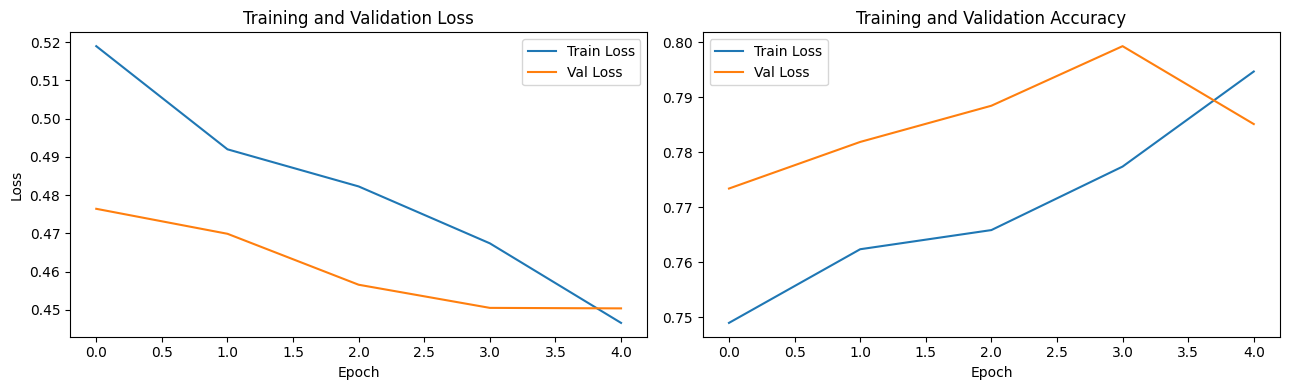

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()


axes[1].plot(history['accuracy'], label='Train Loss')
axes[1].plot(history['val_accuracy'],   label='Val Loss')
axes[1].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves_unet.png', dpi=150)
plt.show()

In [13]:
def per_class_iou(logits, targets, n_classes=N_CLASSES):
    # Convert to numpy to avoid CPU/GPU device mismatch between logits (GPU) and targets (CPU)
    preds = tf.argmax(logits, axis=-1).numpy()          # (B, H, W) int64 numpy
    targets_np = targets.numpy() if hasattr(targets, 'numpy') else np.array(targets)
    ious = []
    for c in range(n_classes):
        pred_c   = (preds == c).astype(np.float32)
        target_c = (targets_np == c).astype(np.float32)
        intersection = np.sum(pred_c * target_c)
        union = np.sum(pred_c) + np.sum(target_c) - intersection
        ious.append(float(intersection / (union + 1e-6)))
    return ious

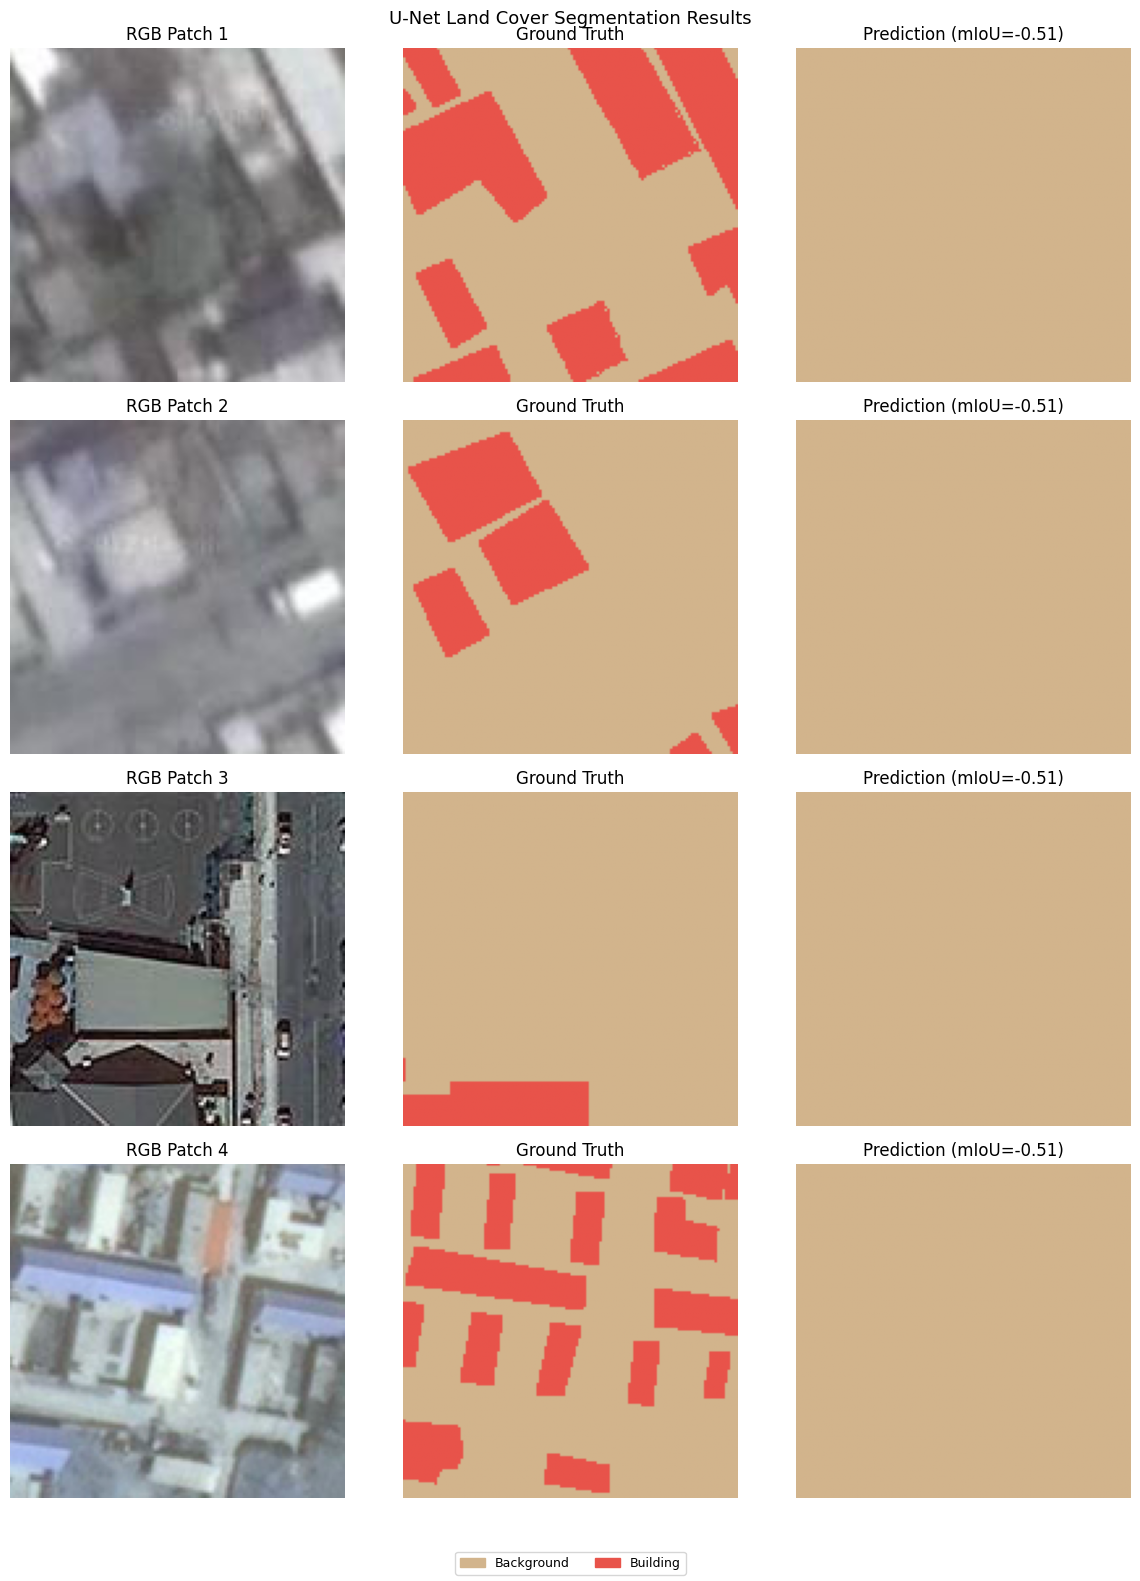

In [ ]:
imgs_batch, lbls_batch = next(iter(val_ds))
logits_batch = model(imgs_batch, training=False)
preds_batch  = tf.argmax(logits_batch, axis=-1).numpy()   # (B, H, W)

cmap   = plt.matplotlib.colors.ListedColormap(CLASS_COLORS)
n_show = min(4, imgs_batch.shape[0])

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    # imgs_batch[i] is (H, W, C) — select band indices 2, 1, 0 for RGB display
    rgb = imgs_batch[i].numpy()[:, :, [2, 1, 0]]
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f'RGB Patch {i+1}')

    axes[i, 1].imshow(lbls_batch[i].numpy(), cmap=cmap, vmin=0, vmax=N_CLASSES - 1)
    axes[i, 1].set_title('Ground Truth')

    axes[i, 2].imshow(logits_batch[i], cmap=cmap, vmin=0, vmax=N_CLASSES - 1)
    patch_iou  = per_class_iou(logits_batch[i:i+1], lbls_batch[i:i+1])
    miou_patch = np.mean(patch_iou)
    axes[i, 2].set_title(f'Prediction (mIoU={miou_patch:.2f})')

for ax in axes.ravel():
    ax.axis('off')

patches = [mpatches.Patch(color=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9)
plt.suptitle('U-Net Land Cover Segmentation Results', fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('unet_predictions.png', dpi=150)
plt.show()

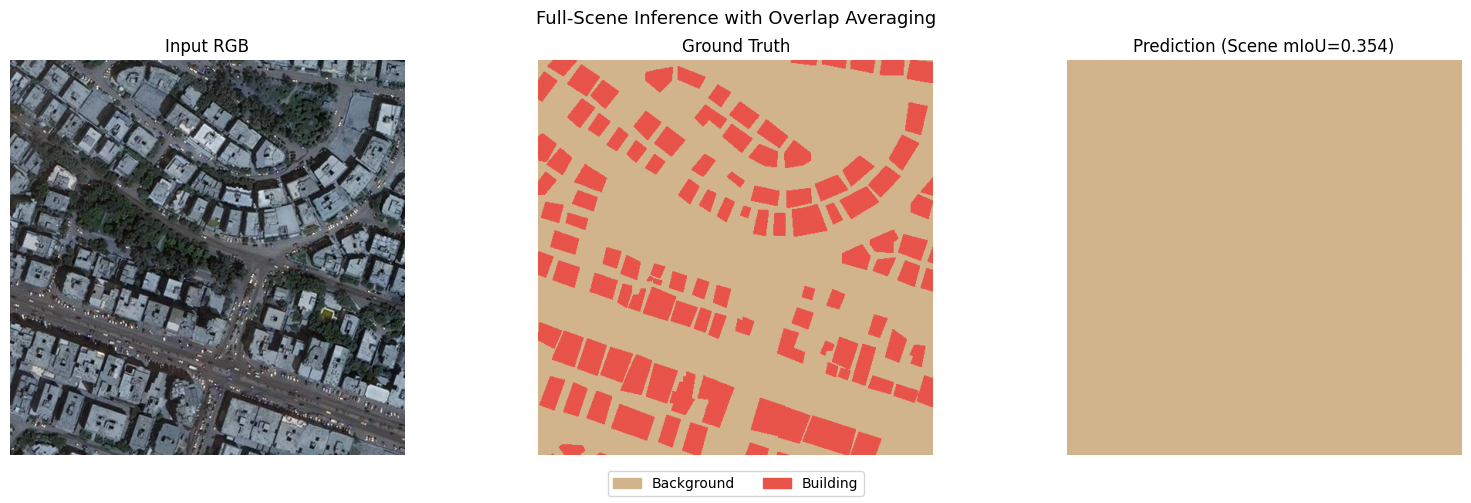


Per-class IoU on full scene:
  Background  : 0.7074
  Building    : 0.0000
  mIoU         : 0.3537


In [ ]:
def predict_full_scene(model, img, patch_size=128, stride=64, n_classes=N_CLASSES):
    """Sliding-window inference with overlap averaging. img: (H, W, C) numpy array."""
    H, W, C = img.shape
    accumulator = np.zeros((H, W, n_classes), dtype=np.float32)
    count_map   = np.zeros((H, W),            dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = img[y:y+patch_size, x:x+patch_size, :]          # (ps, ps, C)
            patch_t = tf.constant(patch[np.newaxis], dtype=tf.float32)  # (1, ps, ps, C)
            logits  = model(patch_t, training=False).numpy()[0]      # (ps, ps, n_classes)
            # Numerically stable softmax
            # exp_l = np.exp(logits - logits.max(axis=-1, keepdims=True))
            # probs = exp_l / exp_l.sum(axis=-1, keepdims=True)
            accumulator[y:y+patch_size, x:x+patch_size, :] += logits
            count_map[y:y+patch_size, x:x+patch_size]       += 1.0

    # accumulator /= count_map[..., np.newaxis]
    return accumulator # (H, W)


pred_scene = predict_full_scene(model, scene_img, patch_size=128, stride=64)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
rgb_scene = scene_img[:, :, [2, 1, 0]]
axes[0].imshow(rgb_scene)
axes[0].set_title('Input RGB')

cmap = plt.matplotlib.colors.ListedColormap(CLASS_COLORS)
axes[1].imshow(scene_label, cmap=cmap, vmin=0, vmax=N_CLASSES - 1)
axes[1].set_title('Ground Truth')

ious = []
for c in range(N_CLASSES):
    inter = ((pred_scene == c) & (scene_label == c)).sum()
    union = ((pred_scene == c) | (scene_label == c)).sum()
    ious.append(inter / (union + 1e-6))
axes[2].imshow(pred_scene[:,:,1], cmap=cmap, vmin=0, vmax=N_CLASSES - 1)
axes[2].set_title(f'Prediction (Scene mIoU={np.mean(ious):.3f})')

for ax in axes:
    ax.axis('off')
patches = [mpatches.Patch(color=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=4)
plt.suptitle('Full-Scene Inference with Overlap Averaging', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('full_scene_prediction.png', dpi=150)
plt.show()

print('\nPer-class IoU on full scene:')
for name, iou in zip(CLASS_NAMES, ious):
    print(f'  {name:12s}: {iou:.4f}')
print(f'  mIoU         : {np.mean(ious):.4f}')